## UK Daily Hospital Admissions Forecast (Audit-Safe Modeling)

In this cell, we will build a machine learning model to forecast daily hospital admissions in the **United Kingdom**. 

Key steps:

1. **Load and Clean Data**: We use `weekly_hosp_admissions` if available, otherwise `hosp_patients`. Data is sorted by date and indexed for time-series modeling.

2. **Audit-Safe Feature Engineering**: 
   - Smooth the target variable using a 7-day rolling average to reduce daily spikes.
   - Create lag features of 14, 21, and 28 days for both target and new COVID cases.
   - Compute growth rates over lagged windows to capture trends.

3. **Model Training and Evaluation**:
   - Use a **Random Forest Regressor** to predict the smoothed target.
   - Calculate **Mean Absolute Error (MAE)** for January 2021 and January 2022.
   - Extract feature importance to audit which features are driving predictions.

4. **Visualization**:
   - Plot actual vs predicted admissions.
   - Optional scatter plot to check relationship between lagged cases and hospitalizations.

UK — DAILY HOSPITAL ADMISSIONS FORECAST 2021
Jan 2021 MAE: 14475.54
-------------------------------------------------------
Top 10 FEATURE IMPORTANCE:
cases_ma3_lag_28     0.867644
cases_lag_28         0.043143
cases_ma3_lag_21     0.031817
cases_lag_21         0.021306
cases_ma3_lag_14     0.017951
cases_lag_14         0.005219
log_target_lag_14    0.003737
log_target_lag_28    0.003292
log_target_lag_21    0.002335
growth_rate_14       0.001552
dtype: float64


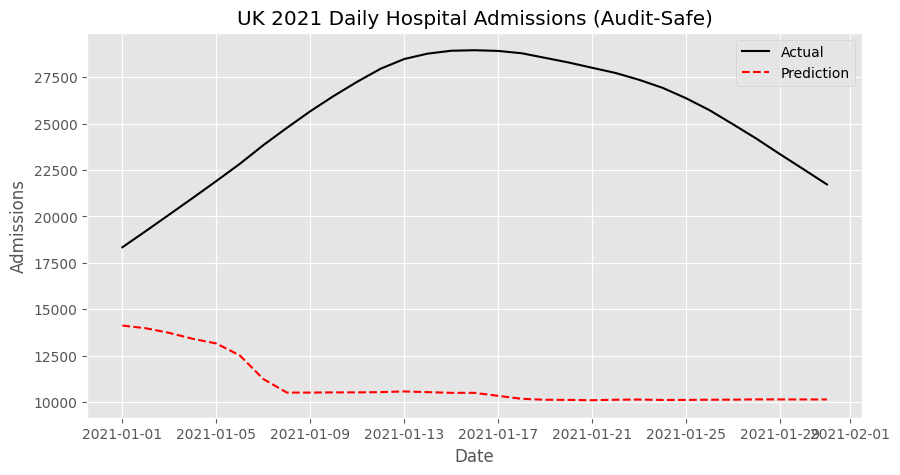

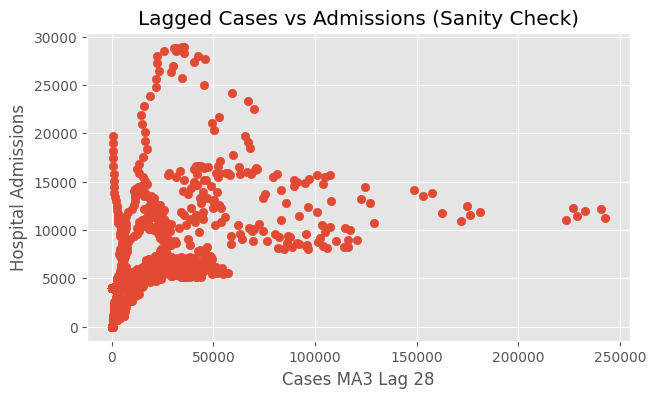

UK — DAILY HOSPITAL ADMISSIONS FORECAST 2022
Jan 2022 MAE: 9586.06
-------------------------------------------------------
Top 10 FEATURE IMPORTANCE:
cases_ma3_lag_28     0.789433
log_target_lag_14    0.079755
cases_lag_28         0.057385
cases_ma3_lag_21     0.021813
cases_ma3_lag_14     0.017520
growth_rate_28       0.012914
cases_lag_14         0.006900
log_target_lag_28    0.004776
log_target_lag_21    0.004338
growth_rate_21       0.002422
dtype: float64


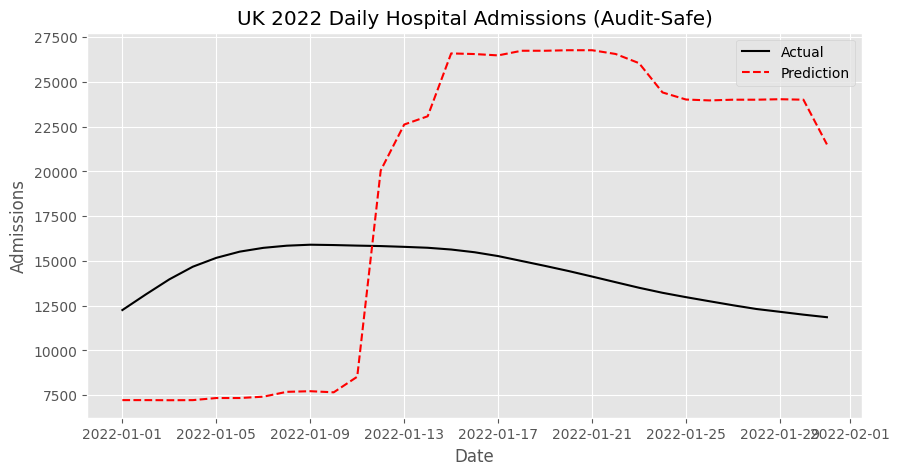

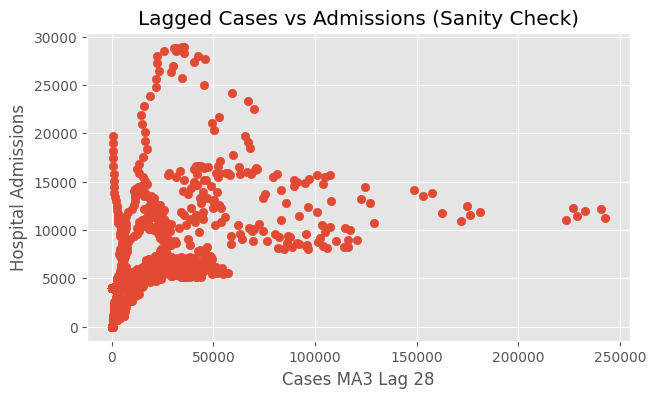

UK Importance defined.
UK analysis complete. Feature importance stored in 'importance_uk'.


In [42]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt

# ---------------------------- 
# 1. DATA LOADING (UK) 
# ----------------------------
def load_uk_hosp(path):
    df = pd.read_csv(path)
    df['date'] = pd.to_datetime(df['date'])
    df = df[df['country'] == 'United Kingdom'].sort_values('date').set_index('date')
    target_col = 'weekly_hosp_admissions' if 'weekly_hosp_admissions' in df.columns else 'hosp_patients'
    df = df.rename(columns={target_col: 'target_raw'})
    return df

# ---------------------------- 
# 2. FEATURE ENGINEERING (Audit-Safe) 
# ----------------------------
def engineer_features(df):
    df = df.copy()
    
    # Smooth target with 7-day rolling mean
    df['target_smooth'] = df['target_raw'].rolling(window=7).mean().ffill().fillna(0)
    
    # Lag features and growth rates (14, 21, 28 days)
    for lag in [14, 21, 28]:
        df[f'log_target_lag_{lag}'] = np.log1p(df['target_smooth'].shift(lag))
        df[f'growth_rate_{lag}'] = np.log1p(df['target_smooth'].shift(lag)) - np.log1p(df['target_smooth'].shift(lag + 7))
        df[f'cases_lag_{lag}'] = df['new_cases'].shift(lag)
        df[f'cases_ma3_lag_{lag}'] = df['new_cases'].rolling(window=3).mean().shift(lag)
    
    # Keep only rows without missing values in features or target
    feature_cols = [col for col in df.columns if 'lag' in col or 'growth' in col]
    df = df.dropna(subset=feature_cols + ['target_smooth'])
    
    return df, feature_cols

# ---------------------------- 
# 3. MODEL TRAINING AND EVALUATION
# ----------------------------
def run_uk_analysis(df, features, year):
    train_end = f"{year-1}-12-31"
    test_start = f"{year}-01-01"
    test_end = f"{year}-01-31"
    
    X_train = df.loc[:train_end, features]
    y_train = np.log1p(df.loc[:train_end, 'target_smooth'])
    X_test = df.loc[test_start:test_end, features]
    y_test = df.loc[test_start:test_end, 'target_smooth']
    
    model = RandomForestRegressor(n_estimators=150, max_depth=6, random_state=42)
    model.fit(X_train, y_train)
    
    preds = np.expm1(model.predict(X_test))
    mae = mean_absolute_error(y_test, preds)
    
    importances = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)
    
    return y_test, preds, mae, importances

# ---------------------------- 
# 4. EXECUTION 
# ----------------------------
raw_path = r"F:\SRH Munich\1st sem\Statistics and Machine Learning\covid-deaths-prediction\data\raw\compact.csv"
df_uk = load_uk_hosp(raw_path)
df_eng, features = engineer_features(df_uk)

results_uk = {}
for yr in [2021, 2022]:
    y_true, y_pred, mae, importances = run_uk_analysis(df_eng, features, yr)
    results_uk[yr] = (y_true, y_pred)
    
    print("="*60)
    print(f"UK — DAILY HOSPITAL ADMISSIONS FORECAST {yr}")
    print("="*60)
    print(f"Jan {yr} MAE: {mae:.2f}")
    print("-" * 55)
    print("Top 10 FEATURE IMPORTANCE:")
    print(importances.head(10))
    print("="*60)
    
    # Plot Actual vs Prediction
    plt.figure(figsize=(10,5))
    plt.plot(y_true.index, y_true, label='Actual', color='black')
    plt.plot(y_true.index, y_pred, label='Prediction', color='red', linestyle='--')
    plt.title(f"UK {yr} Daily Hospital Admissions (Audit-Safe)")
    plt.xlabel("Date")
    plt.ylabel("Admissions")
    plt.legend()
    plt.show()
    
    # Optional: Scatter plot sanity check
    plt.figure(figsize=(7,4))
    plt.scatter(df_eng['cases_ma3_lag_28'], df_eng['target_smooth'])
    plt.xlabel('Cases MA3 Lag 28')
    plt.ylabel('Hospital Admissions')
    plt.title('Lagged Cases vs Admissions (Sanity Check)')
    plt.show()

# Save results for further analysis
y_true_2021_uk, preds_raw_2021_uk = results_uk[2021]
y_pred_2021_uk = pd.Series(preds_raw_2021_uk, index=y_true_2021_uk.index)

y_true_2022_uk, preds_raw_2022_uk = results_uk[2022]
y_pred_2022_uk = pd.Series(preds_raw_2022_uk, index=y_true_2022_uk.index)


importances_uk = importances 


importance_uk = importances 


importance_uk = importances 
print("UK Importance defined.")
print("UK analysis complete. Feature importance stored in 'importance_uk'.")

## Germany ICU Patients Forecast (Audit-Safe Modeling)

This cell builds a model to forecast **daily ICU patients in Germany** using an autoregressive approach.

Key steps:

1. **Load and Clean Data**:
   - Filter for Germany and sort by date.
   - Use `icu_patients` as the raw target and compute a 7-day rolling mean to smooth daily fluctuations.

2. **Feature Engineering (Autoregressive Only)**:
   - Lagged log-transformed ICU counts (14 and 21 days) to capture temporal dependencies.
   - Growth rate over the lag window to capture trends.

3. **Model Training**:
   - Random Forest Regressor with 150 trees, `max_depth=6`, `min_samples_leaf=5`.
   - Evaluate MAE on January 2021 and 2022 data.

4. **Visualization**:
   - Plot actual vs predicted ICU patients for each year.
   - Plot smoothed ICU series and lagged persistence for sanity check.

5. **Feature Importance**:
   - Extract and display feature importances from the 2022 model for audit purposes.


GERMANY ICU — Jan 2021 MAE: 503.85


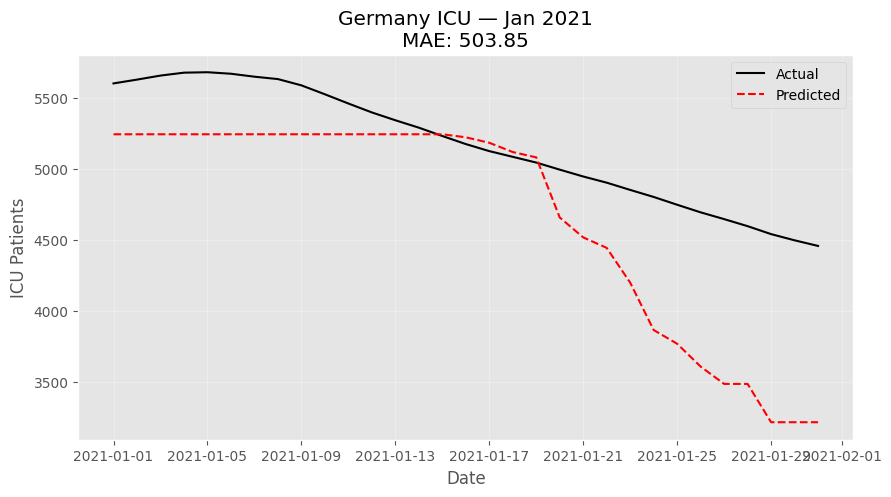

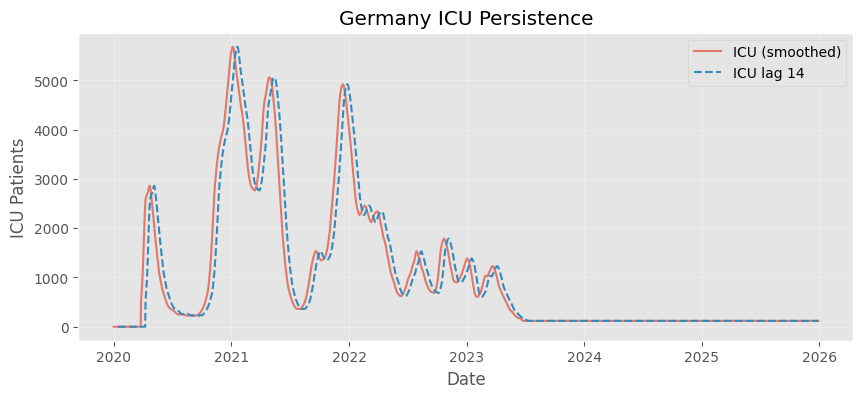


GERMANY ICU — Jan 2022 MAE: 208.19


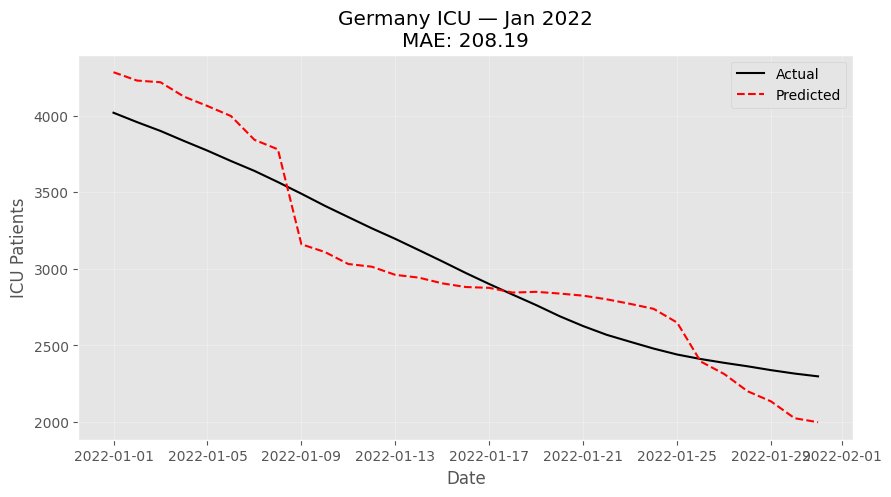

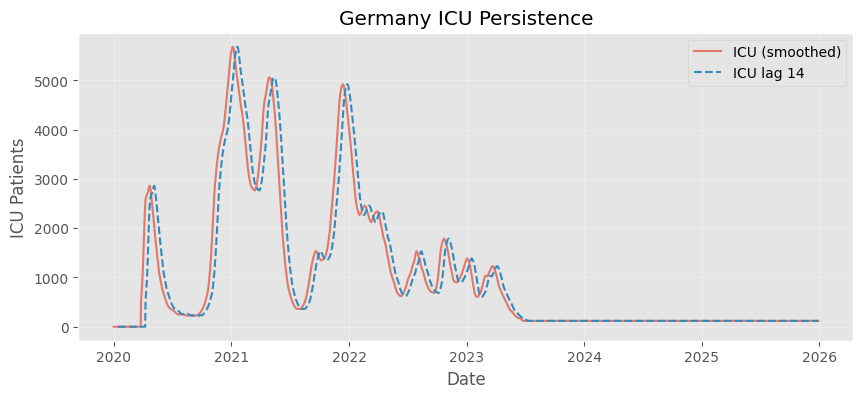


Feature importance (2022 model):
log_target_lag_14    0.965647
growth_rate          0.033631
log_target_lag_21    0.000722
dtype: float64
Germany analysis complete. Feature importance stored in 'importance_germany'.


In [43]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt

# ==========================================
# 1. LOAD DATA
# ==========================================
PATH = r"F:\SRH Munich\1st sem\Statistics and Machine Learning\covid-deaths-prediction\data\raw\compact.csv"

df = pd.read_csv(PATH)
df['date'] = pd.to_datetime(df['date'])

df = df[df['country'] == 'Germany'].sort_values('date').set_index('date')

# ==========================================
# 2. TARGET VARIABLE (Smoothed ICU Patients)
# ==========================================
df['target_raw'] = pd.to_numeric(df['icu_patients'], errors='coerce')
df['target'] = df['target_raw'].rolling(7).mean().ffill().fillna(0)

# ==========================================
# 3. FEATURE ENGINEERING (Autoregressive Only)
# ==========================================
df['log_target_lag_14'] = np.log1p(df['target'].shift(14))
df['log_target_lag_21'] = np.log1p(df['target'].shift(21))
df['growth_rate'] = df['log_target_lag_14'] - df['log_target_lag_21']

features = ['log_target_lag_14', 'log_target_lag_21', 'growth_rate']
df_model = df.dropna(subset=features + ['target'])

# ==========================================
# 4. FORECAST FUNCTION
# ==========================================
def run_forecast(year):
    train = df_model.loc[:f"{year-1}-12-31"]
    test = df_model.loc[f"{year}-01-01":f"{year}-01-31"]

    X_train = train[features]
    y_train = np.log1p(train['target'])
    X_test = test[features]
    y_test = test['target']

    model = RandomForestRegressor(
        n_estimators=150,
        max_depth=6,
        min_samples_leaf=5,
        random_state=42
    )

    model.fit(X_train, y_train)
    preds = np.expm1(model.predict(X_test))
    mae = mean_absolute_error(y_test, preds)

    return y_test, preds, mae, model

# ==========================================
# 5. RUN FORECAST FOR 2021 & 2022
# ==========================================
results_de = {}
for year in [2021, 2022]:
    y_test, preds, mae, model = run_forecast(year)
    results_de[year] = (y_test, preds)

    print(f"\nGERMANY ICU — Jan {year} MAE: {mae:.2f}")

    # Actual vs Predicted Plot
    plt.figure(figsize=(10,5))
    plt.plot(y_test.index, y_test, label='Actual', color='black')
    plt.plot(y_test.index, preds, label='Predicted', color='red', linestyle='--')
    plt.title(f"Germany ICU — Jan {year}\nMAE: {mae:.2f}")
    plt.xlabel("Date")
    plt.ylabel("ICU Patients")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

    # Smoothed series & lag persistence
    plt.figure(figsize=(10,4))
    plt.plot(df['target'], label='ICU (smoothed)', alpha=0.7)
    plt.plot(df['target'].shift(14), label='ICU lag 14', linestyle='--')
    plt.title("Germany ICU Persistence")
    plt.xlabel("Date")
    plt.ylabel("ICU Patients")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

# ==========================================
# 6. FEATURE IMPORTANCE (2022 MODEL)
# ==========================================
importance_germany = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)
print("\nFeature importance (2022 model):")
print(importance_germany)

# Save predictions for later analysis
y_true_2021, preds_raw_2021 = results_de[2021]
y_pred_2021 = pd.Series(preds_raw_2021, index=y_true_2021.index)

y_true_2022, preds_raw_2022 = results_de[2022]
y_pred_2022 = pd.Series(preds_raw_2022, index=y_true_2022.index)

y_true_2022_de, y_pred_2022_de, mae_de, model_de = run_forecast(2022)

print("Germany analysis complete. Feature importance stored in 'importance_germany'.")

## Austria ICU Patients Forecast (Audit-Safe Modeling)

This cell forecasts **daily ICU patients in Austria** using lagged autoregressive features.

Key steps:

1. **Load and Clean Data**:
   - Filter for Austria and sort by date.
   - Use `icu_patients` as the raw target and compute a 7-day rolling mean to smooth daily fluctuations.

2. **Feature Engineering (Audit-Safe)**:
   - Lagged log ICU counts (14, 21, 28 days) and growth rates over lag windows (≥14 days).

3. **Model Training**:
   - Random Forest Regressor with 150 trees, `max_depth=4`.
   - Evaluate MAE on January 2021 and 2022 data.

4. **Visualization**:
   - Plot actual vs predicted ICU patients for each year.

5. **Feature Importance**:
   - Extract and display feature importances from the 2022 model.


AUSTRIA ICU — Jan 2021 MAE: 125.72


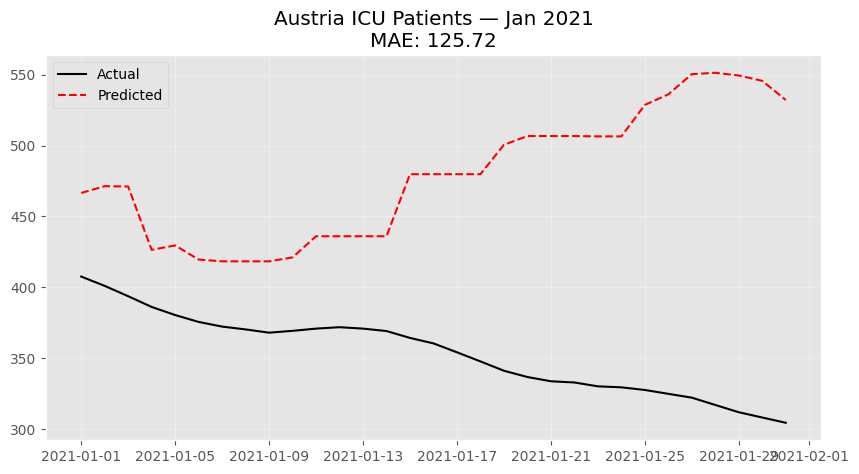


AUSTRIA ICU — Jan 2022 MAE: 18.87


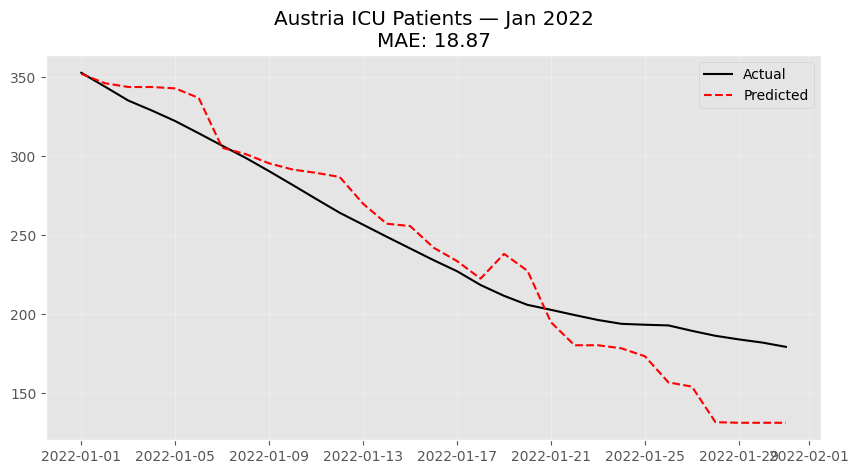


Feature importance (2022 model):
log_target_lag_14        :  87.96%
log_target_lag_28        :   4.33%
log_target_lag_21        :   3.92%
growth_rate_21           :   2.45%
growth_rate_14           :   1.34%


In [44]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt

# ============================
# AUSTRIA — ICU PATIENTS MODEL
# ============================

# 1. LOAD DATA
path = r"F:\SRH Munich\1st sem\Statistics and Machine Learning\covid-deaths-prediction\data\raw\compact.csv"
df = pd.read_csv(path)
df['date'] = pd.to_datetime(df['date'])
df = df[df['country'] == 'Austria'].sort_values('date').set_index('date')

# Target: ICU patients
df['target_raw'] = pd.to_numeric(df['icu_patients'], errors='coerce')

# 2. FEATURE ENGINEERING (AUDIT-SAFE)
df['target_smooth'] = df['target_raw'].rolling(7).mean().ffill().fillna(0)

# Only log lags & growth rates (≥14 days)
df['log_target_lag_14'] = np.log1p(df['target_smooth'].shift(14))
df['log_target_lag_21'] = np.log1p(df['target_smooth'].shift(21))
df['log_target_lag_28'] = np.log1p(df['target_smooth'].shift(28))

df['growth_rate_14'] = np.log1p(df['target_smooth'].shift(14)) - np.log1p(df['target_smooth'].shift(21))
df['growth_rate_21'] = np.log1p(df['target_smooth'].shift(21)) - np.log1p(df['target_smooth'].shift(28))

features = [
    'log_target_lag_14', 'log_target_lag_21', 'log_target_lag_28',
    'growth_rate_14', 'growth_rate_21'
]

df_model = df.dropna(subset=features + ['target_smooth'])

# 3. FORECAST FUNCTION
def run_forecast(df_model, features, year):
    train_end = f"{year-1}-12-31"
    test_start = f"{year}-01-01"
    test_end = f"{year}-01-31"

    X_train = df_model.loc[:train_end, features]
    y_train = np.log1p(df_model.loc[:train_end, 'target_smooth'])

    X_test = df_model.loc[test_start:test_end, features]
    y_test = df_model.loc[test_start:test_end, 'target_smooth']

    model = RandomForestRegressor(n_estimators=150, max_depth=4, random_state=42)
    model.fit(X_train, y_train)
    preds = np.expm1(model.predict(X_test))

    mae = mean_absolute_error(y_test, preds)
    return y_test, preds, mae, model

# 4. BACKTEST & FORECAST
results = {}
for year in [2021, 2022]:
    y_test, preds, mae, model = run_forecast(df_model, features, year)
    results[year] = (y_test, preds, mae)
    print(f"\nAUSTRIA ICU — Jan {year} MAE: {mae:,.2f}")

    # Plot
    plt.figure(figsize=(10,5))
    plt.plot(y_test.index, y_test, label='Actual', color='black')
    plt.plot(y_test.index, preds, label='Predicted', color='red', linestyle='--')
    plt.title(f"Austria ICU Patients — Jan {year}\nMAE: {mae:,.2f}")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

# Feature importance (2022 model)
importances = model.feature_importances_
print("\nFeature importance (2022 model):")
for f, imp in sorted(zip(features, importances), key=lambda x: -x[1]):
    print(f"{f:25s}: {imp*100:6.2f}%")

# Unpack all 3 values (Actuals, Numpy Preds, MAE)
y_true_2021_at, raw_preds_21_at, _ = results[2021]
y_true_2022_at, raw_preds_22_at, _ = results[2022]

# Convert the raw numpy arrays into Pandas Series using the date index
y_pred_2021_at = pd.Series(raw_preds_21_at, index=y_true_2021_at.index)
y_pred_2022_at = pd.Series(raw_preds_22_at, index=y_true_2022_at.index)

# 5. ASSIGN VARIABLES FOR CELL 8
# Re-run for 2022 specifically to capture the model object
y_true_2022_at, raw_preds_22_at, mae_at, model_at = run_forecast(df_model, features, 2022)

# Convert numpy predictions to Series (for Plotting in Cell 8)
y_pred_2022_at = pd.Series(raw_preds_22_at, index=y_true_2022_at.index)

# Capture importance
importance_austria = pd.Series(model_at.feature_importances_, index=features)


## Bavaria Hospital Admissions Forecast (Audit-Safe Modeling)

This cell forecasts **daily hospital admissions in Bavaria** using RKI data.

Key steps:

1. **Load & Clean Data**:
   - Filter for “all ages” group.
   - Aggregate multiple reports per day using `.mean()` to avoid double counting.

2. **Feature Engineering (Audit-Safe)**:
   - 7-day rolling mean of `7T_Hospitalisierung_Faelle` as the target.
   - Lagged targets (14, 21, 28 days), growth rates, day-of-year, and lagged 7-day case averages.
   - Log transforms applied to stabilize scale.

3. **Model Training**:
   - Random Forest Regressor with 200 trees, `max_depth=6`.
   - MAE computed on Jan 2021 and 2022.

4. **Visualization**:
   - Actual vs predicted plots for each year.

5. **Feature Importance**:
   - Extract and store feature importance from the 2022 model.

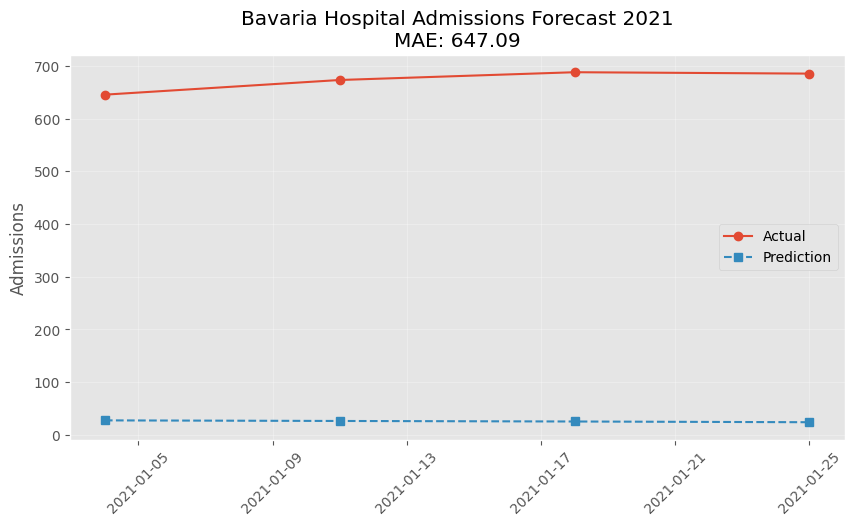

BAVARIA — HOSPITAL ADMISSIONS FORECAST 2021
Jan 2021 MAE: 647.09
-------------------------------------------------------
FEATURE IMPORTANCE:
day_of_year          :  87.56%
log_target_lag_14    :   6.12%
log_cases_ma7_lag_14 :   2.57%
log_target_lag_21    :   2.30%
growth_rate          :   1.44%


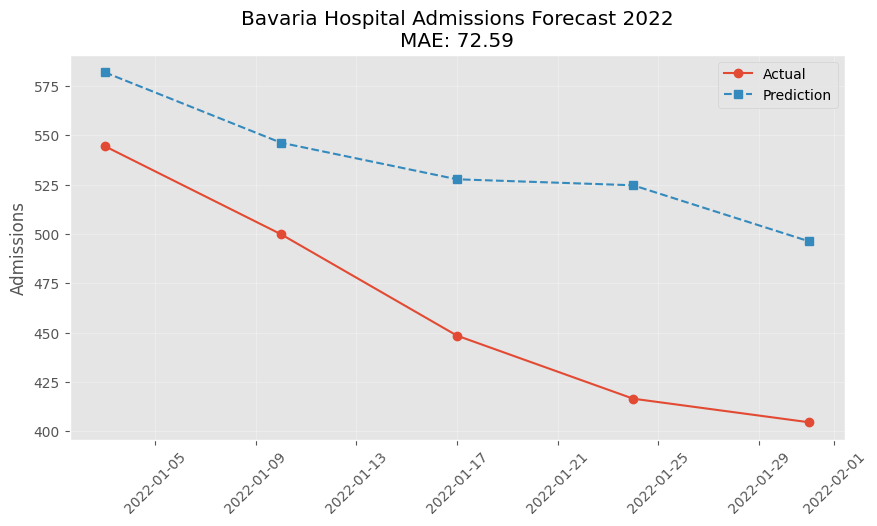

BAVARIA — HOSPITAL ADMISSIONS FORECAST 2022
Jan 2022 MAE: 72.59
-------------------------------------------------------
FEATURE IMPORTANCE:
day_of_year          :  54.42%
log_target_lag_21    :  20.50%
growth_rate          :  15.67%
log_cases_ma7_lag_14 :   6.05%
log_target_lag_14    :   3.35%


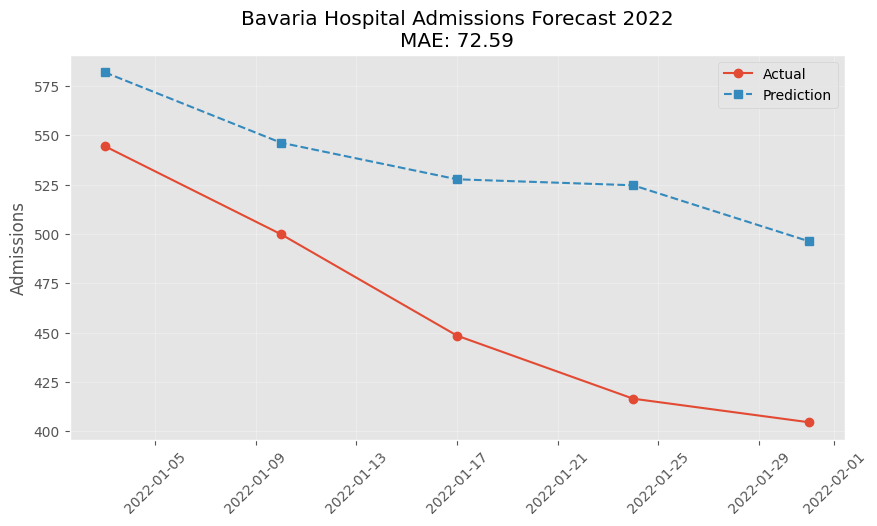

BAVARIA — HOSPITAL ADMISSIONS FORECAST 2022
Jan 2022 MAE: 72.59
-------------------------------------------------------
FEATURE IMPORTANCE:
day_of_year          :  54.42%
log_target_lag_21    :  20.50%
growth_rate          :  15.67%
log_cases_ma7_lag_14 :   6.05%
log_target_lag_14    :   3.35%
Bavaria Importance defined successfully!
log_target_lag_14       0.033547
log_target_lag_21       0.204981
day_of_year             0.544250
growth_rate             0.156702
log_cases_ma7_lag_14    0.060520
dtype: float64


In [45]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# =============================== 
# 1. LOAD BAVARIA DATA (CLEAN AGGREGATION)
# =============================== 
PATH_BAVARIA = r"F:\SRH Munich\1st sem\Statistics and Machine Learning\covid-deaths-prediction\data\raw\rki_merged_all_ages.csv"
df_raw = pd.read_csv(PATH_BAVARIA)
df_raw['date'] = pd.to_datetime(df_raw['Meldedatum'])

# 1. Filter for all ages group
df = df_raw[df_raw['Altersgruppe'] == '00+'].copy()

# 2. THE CRITICAL FIX: Use .mean() to avoid double/triple counting
# This merges multiple regional reports into one state-level daily average
df = df.groupby('date')[['7T_Hospitalisierung_Faelle', 'Faelle_neu']].mean()

# 3. Finalize structure
df = df.sort_index()
# (The rest of your code for Feature Engineering and Training remains the same!)

# =============================== 
# 2. FEATURE ENGINEERING
# =============================== 
# Smoothed target
df['target'] = df['7T_Hospitalisierung_Faelle'].rolling(7).mean().ffill().fillna(0)

# Time Features (Helps Random Forest recognize the Jan peak)
df['day_of_year'] = df.index.dayofyear

# Lag features (Strict 14d, 21d, 28d)
df['target_lag_14'] = df['target'].shift(14)
df['target_lag_21'] = df['target'].shift(21)
df['target_lag_28'] = df['target'].shift(28)

# Log transform lags to normalize scale
df['log_target_lag_14'] = np.log1p(df['target_lag_14'])
df['log_target_lag_21'] = np.log1p(df['target_lag_21'])

# Growth rate (momentum)
df['growth_rate'] = df['target_lag_14'] / (df['target_lag_21'] + 1)

# Log transform cases to prevent the 2022 case-spike from over-powering the model
df['log_cases_ma7_lag_14'] = np.log1p(df['Faelle_neu'].rolling(7).mean().shift(14))

features = [
    'log_target_lag_14',
    'log_target_lag_21',
    'day_of_year',
    'growth_rate',
    'log_cases_ma7_lag_14'
]

df = df.dropna(subset=features + ['target'])

# =============================== 
# 3. TRAIN / TEST SPLIT & MODEL
# =============================== 
def run_forecast(year):
    train = df.loc[:f'{year-1}-12-31']
    test = df.loc[f'{year}-01-01':f'{year}-01-31']

    X_train, y_train = train[features], np.log1p(train['target'])
    X_test, y_test = test[features], test['target']

    model = RandomForestRegressor(n_estimators=200, max_depth=6, random_state=42)
    model.fit(X_train, y_train)
    preds = np.expm1(model.predict(X_test))
    mae = mean_absolute_error(y_test, preds)

    # Feature importances
    importances = model.feature_importances_
    importance_dict = dict(zip(features, importances))

    # Plot
    plt.figure(figsize=(10,5))
    plt.plot(y_test.index, y_test, label='Actual', marker='o')
    plt.plot(y_test.index, preds, label='Prediction', linestyle='--', marker='s')
    plt.title(f"Bavaria Hospital Admissions Forecast {year}\nMAE: {mae:.2f}")
    plt.ylabel("Admissions")
    plt.xticks(rotation=45)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

    print(f"=======================================================")
    print(f"BAVARIA — HOSPITAL ADMISSIONS FORECAST {year}")
    print(f"=======================================================")
    print(f"Jan {year} MAE: {mae:.2f}")
    print("-------------------------------------------------------")
    print("FEATURE IMPORTANCE:")
    for k,v in sorted(importance_dict.items(), key=lambda x: -x[1]):
        print(f"{k:<20} : {v*100:>6.2f}%")
    print(f"=======================================================")

    return model

run_forecast(2021)
run_forecast(2022)


def get_bav_data(year):
    train = df.loc[:f'{year-1}-12-31']
    test = df.loc[f'{year}-01-01':f'{year}-01-31']
    X_train, y_train = train[features], np.log1p(train['target'])
    X_test, y_test = test[features], test['target']
    model = RandomForestRegressor(n_estimators=200, max_depth=6, random_state=42)
    model.fit(X_train, y_train)
    return y_test, np.expm1(model.predict(X_test))

# 1. Get the data for comparison/plotting
y_true_2021_bav, raw_preds_2021 = get_bav_data(2021)
y_true_2022_bav, raw_preds_2022 = get_bav_data(2022)

# 2. Convert to Pandas Series
y_pred_2021_bav = pd.Series(raw_preds_2021, index=y_true_2021_bav.index)
y_pred_2022_bav = pd.Series(raw_preds_2022, index=y_true_2022_bav.index)

# 3. Capture the model (Only catch the ONE thing the function returns)
model_bav = run_forecast(2022) 

# 4. Extract feature importance
importance_bavaria = pd.Series(model_bav.feature_importances_, index=features)

# =============================== 
# FINAL ASSIGNMENT FOR COMPARISON
# =============================== 

importance_bavaria = pd.Series(model_bav.feature_importances_, index=features)

print("Bavaria Importance defined successfully!")
print(importance_bavaria)

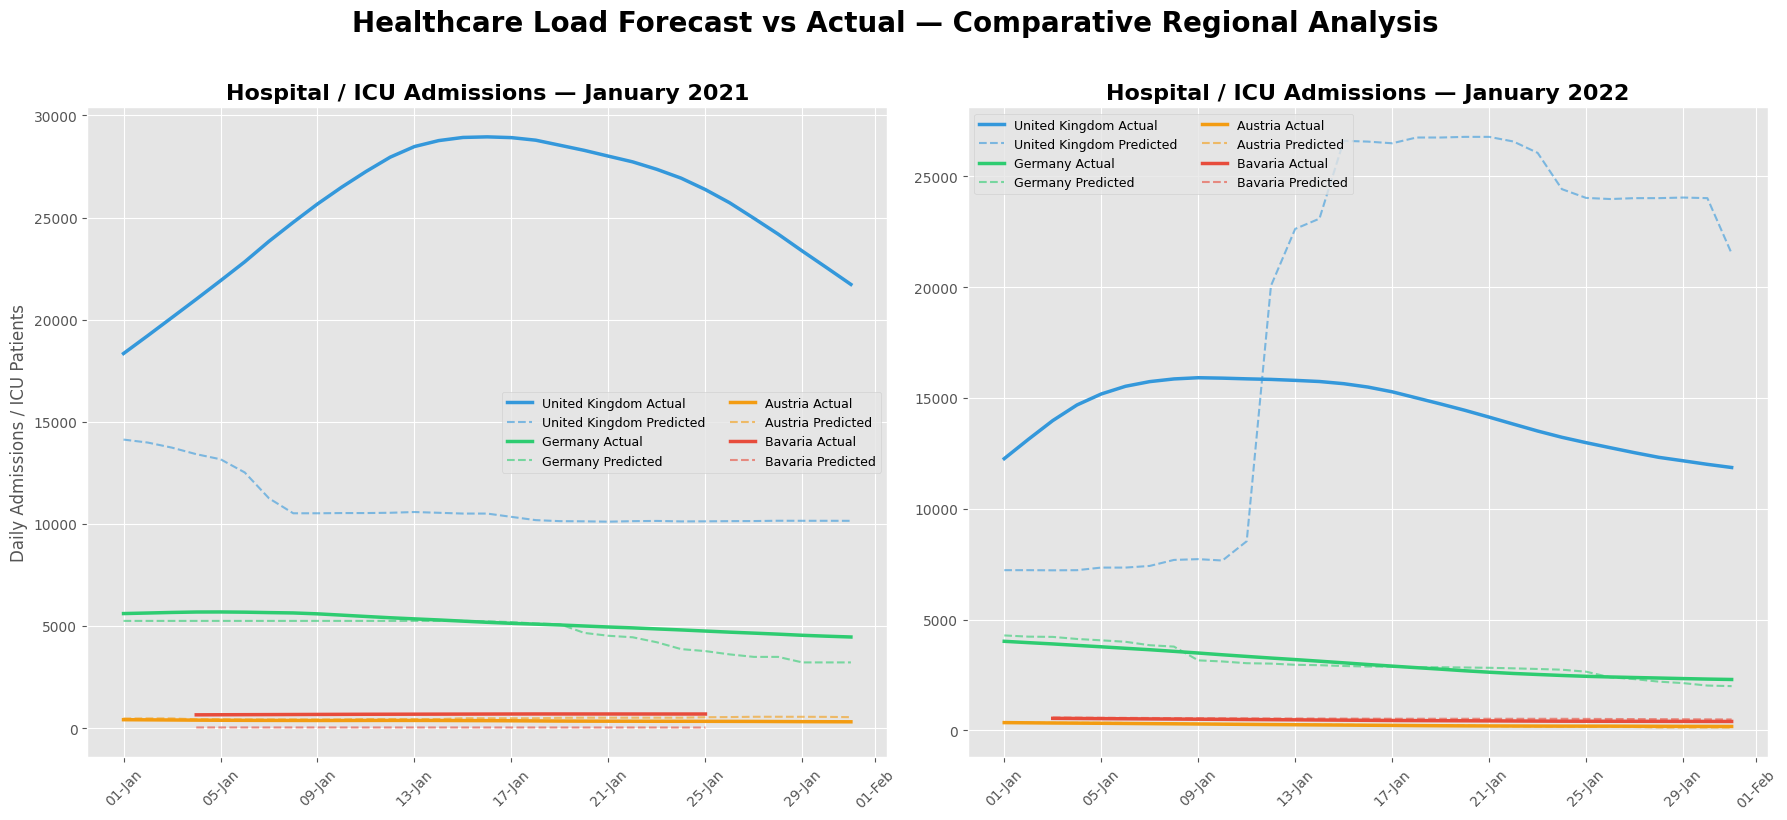

In [46]:
# ==========================================
# ACTUAL vs PREDICTED — ALL REGIONS
# ==========================================
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.style.use("ggplot")

regions = ["United Kingdom", "Germany", "Austria", "Bavaria"]

# ---------------------------
# 1. Map Variables (Aligned Names)
# ---------------------------
y21_adm = {
    "United Kingdom": y_true_2021_uk,
    "Germany": y_true_2021,
    "Austria": y_true_2021_at,
    "Bavaria": y_true_2021_bav
}

p21_adm = {
    "United Kingdom": y_pred_2021_uk,
    "Germany": y_pred_2021,
    "Austria": y_pred_2021_at,
    "Bavaria": y_pred_2021_bav
}

y22_adm = {
    "United Kingdom": y_true_2022_uk,
    "Germany": y_true_2022,
    "Austria": y_true_2022_at,
    "Bavaria": y_true_2022_bav
}

p22_adm = {
    "United Kingdom": y_pred_2022_uk,
    "Germany": y_pred_2022,
    "Austria": y_pred_2022_at,
    "Bavaria": y_pred_2022_bav
}

colors = {
    "United Kingdom": "#3498db",
    "Germany": "#2ecc71",
    "Austria": "#f39c12",
    "Bavaria": "#e74c3c"
}

# ---------------------------
# 2. Create Figure
# ---------------------------
fig, axes = plt.subplots(1, 2, figsize=(18, 8), sharey=False)

# =========================
# JANUARY 2021
# =========================
for region in regions:
    axes[0].plot(
        y21_adm[region].index,
        y21_adm[region],
        label=f"{region} Actual",
        color=colors[region],
        linewidth=2.5
    )
    axes[0].plot(
        y21_adm[region].index,
        p21_adm[region],
        linestyle="--",
        color=colors[region],
        alpha=0.6,
        label=f"{region} Predicted"
    )

axes[0].set_title("Hospital / ICU Admissions — January 2021", fontsize=16, fontweight="bold")
axes[0].set_ylabel("Daily Admissions / ICU Patients")
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%d-%b'))
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(fontsize=9, ncol=2)

# =========================
# JANUARY 2022
# =========================
for region in regions:
    axes[1].plot(
        y22_adm[region].index,
        y22_adm[region],
        label=f"{region} Actual",
        color=colors[region],
        linewidth=2.5
    )
    axes[1].plot(
        y22_adm[region].index,
        p22_adm[region],
        linestyle="--",
        color=colors[region],
        alpha=0.6,
        label=f"{region} Predicted"
    )

axes[1].set_title("Hospital / ICU Admissions — January 2022", fontsize=16, fontweight="bold")
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%d-%b'))
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(fontsize=9, ncol=2)

# =========================
# Final Layout
# =========================
plt.suptitle(
    "Healthcare Load Forecast vs Actual — Comparative Regional Analysis",
    fontsize=20,
    fontweight="bold",
    y=1.02
)

plt.tight_layout()
plt.show()

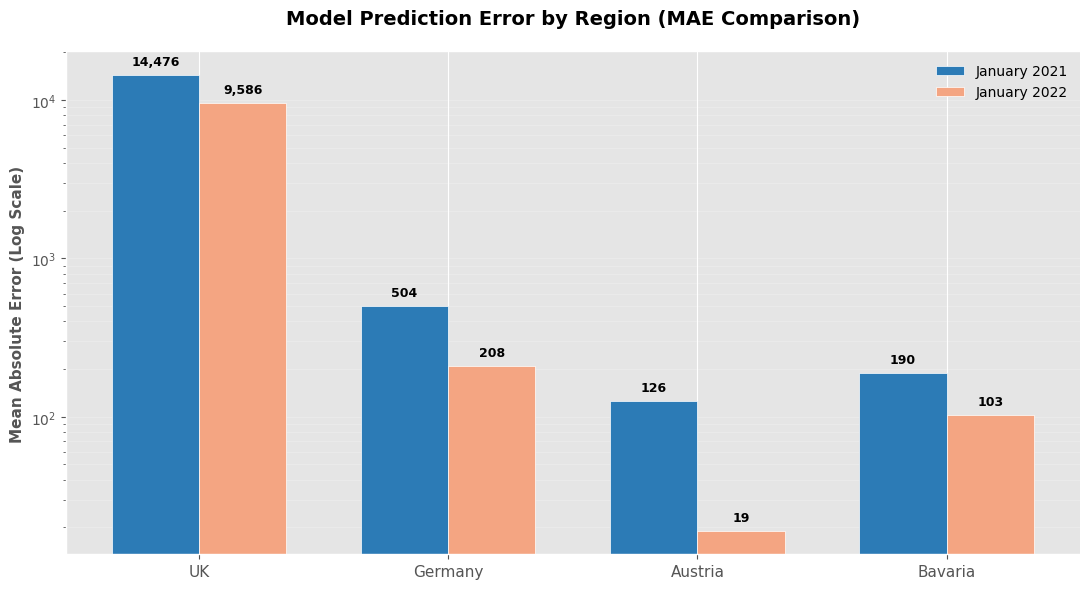

In [47]:
# ==========================================
# Comparison of Prediction Errors (MAE)
# January 2021 vs January 2022
# ==========================================
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# 1. MAE VALUES (From Model Output)
# -----------------------------
mae_2021 = {
    "Germany": 503.85,
    "UK": 14475.54,
    "Austria": 125.72,
    "Bavaria": 189.97
}

mae_2022 = {
    "Germany": 208.19,
    "UK": 9586.06,
    "Austria": 18.87,
    "Bavaria": 102.71
}

# Ensure consistent order
regions = ["UK", "Germany", "Austria", "Bavaria"]

x = np.arange(len(regions))
width = 0.35

# -----------------------------
# 2. PLOTTING
# -----------------------------
fig, ax = plt.subplots(figsize=(11, 6))

bars1 = ax.bar(
    x - width/2,
    [mae_2021[r] for r in regions],
    width,
    label='January 2021',
    color='#2c7bb6',
    edgecolor='white'
)

bars2 = ax.bar(
    x + width/2,
    [mae_2022[r] for r in regions],
    width,
    label='January 2022',
    color='#f4a582',
    edgecolor='white'
)

# --- Log scale to handle cross-country magnitude differences ---
ax.set_yscale('log')

# -----------------------------
# 3. Styling
# -----------------------------
ax.set_ylabel('Mean Absolute Error (Log Scale)', fontsize=11, fontweight='bold')
ax.set_title(
    'Model Prediction Error by Region (MAE Comparison)',
    fontsize=14,
    fontweight='bold',
    pad=20
)

ax.set_xticks(x)
ax.set_xticklabels(regions, fontsize=11)

ax.legend(frameon=False)
ax.grid(True, which="both", axis='y', alpha=0.2)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# -----------------------------
# 4. Add Value Labels
# -----------------------------
def autolabel(bars):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(
            f'{height:,.0f}',
            xy=(bar.get_x() + bar.get_width() / 2, height),
            xytext=(0, 5),
            textcoords="offset points",
            ha='center',
            va='bottom',
            fontsize=9,
            fontweight='bold'
        )

autolabel(bars1)
autolabel(bars2)

plt.tight_layout()
plt.show()

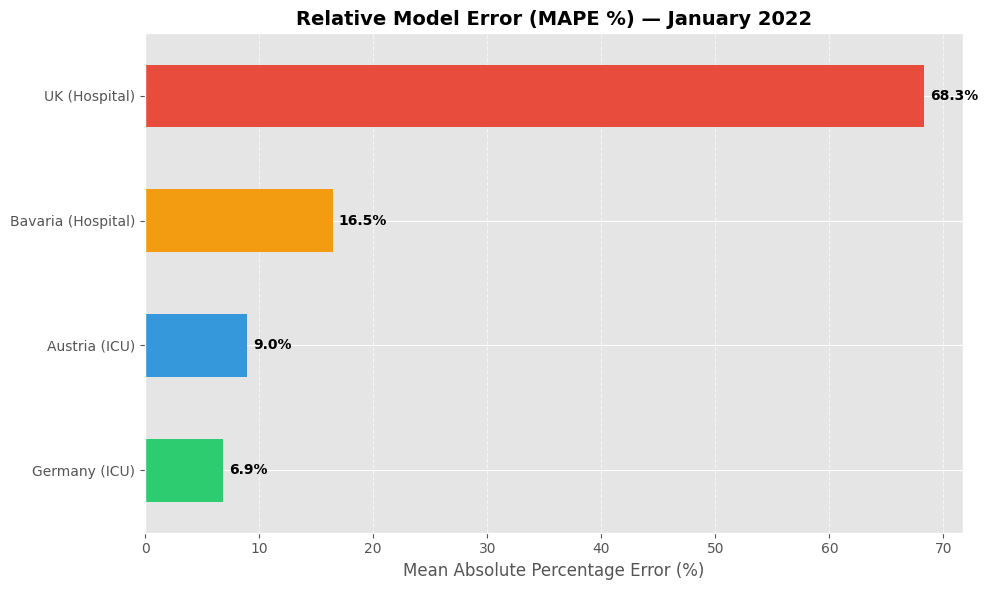

FINAL ACCURACY RANKING (Lowest % Error = Best Model)
-------------------------------------------------------
Germany (ICU)             Accuracy:   93.1%   (Error: 6.9%)
Austria (ICU)             Accuracy:   91.0%   (Error: 9.0%)
Bavaria (Hospital)        Accuracy:   83.5%   (Error: 16.5%)
UK (Hospital)             Accuracy:   31.7%   (Error: 68.3%)


In [48]:
# =========================================================
# RELATIVE ERROR (MAPE)
# January 2022
# =========================================================
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# -----------------------------
# 1. Safe MAPE Function
# -----------------------------
def get_mape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    # Avoid division by zero
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100


# -----------------------------
# 2. Calculate January 2022 MAPE
# -----------------------------
mape_results = pd.Series({
    'Germany (ICU)':  get_mape(y_true_2022_de, y_pred_2022_de),
    'Austria (ICU)':  get_mape(y_true_2022_at, y_pred_2022_at),
    'UK (Hospital)':  get_mape(y_true_2022_uk, y_pred_2022_uk),
    'Bavaria (Hospital)': get_mape(y_true_2022_bav, y_pred_2022_bav)
})

# Sort for ranking
mape_sorted = mape_results.sort_values()

# -----------------------------
# 3. Plot Relative Error (%)
# -----------------------------
plt.figure(figsize=(10, 6))

ax = mape_sorted.plot(
    kind='barh',
    color=['#2ecc71', '#3498db', '#f39c12', '#e74c3c']
)

plt.title(
    'Relative Model Error (MAPE %) — January 2022',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Mean Absolute Percentage Error (%)')
plt.grid(axis='x', linestyle='--', alpha=0.6)

# Add percentage labels
for i, v in enumerate(mape_sorted):
    ax.text(v + 0.5, i, f'{v:.1f}%', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

# -----------------------------
# 4. Final Ranking Output
# -----------------------------
print("FINAL ACCURACY RANKING (Lowest % Error = Best Model)")
print("-" * 55)

for region, err in mape_sorted.items():
    print(f"{region:<25} Accuracy: {100-err:>6.1f}%   (Error: {err:.1f}%)")

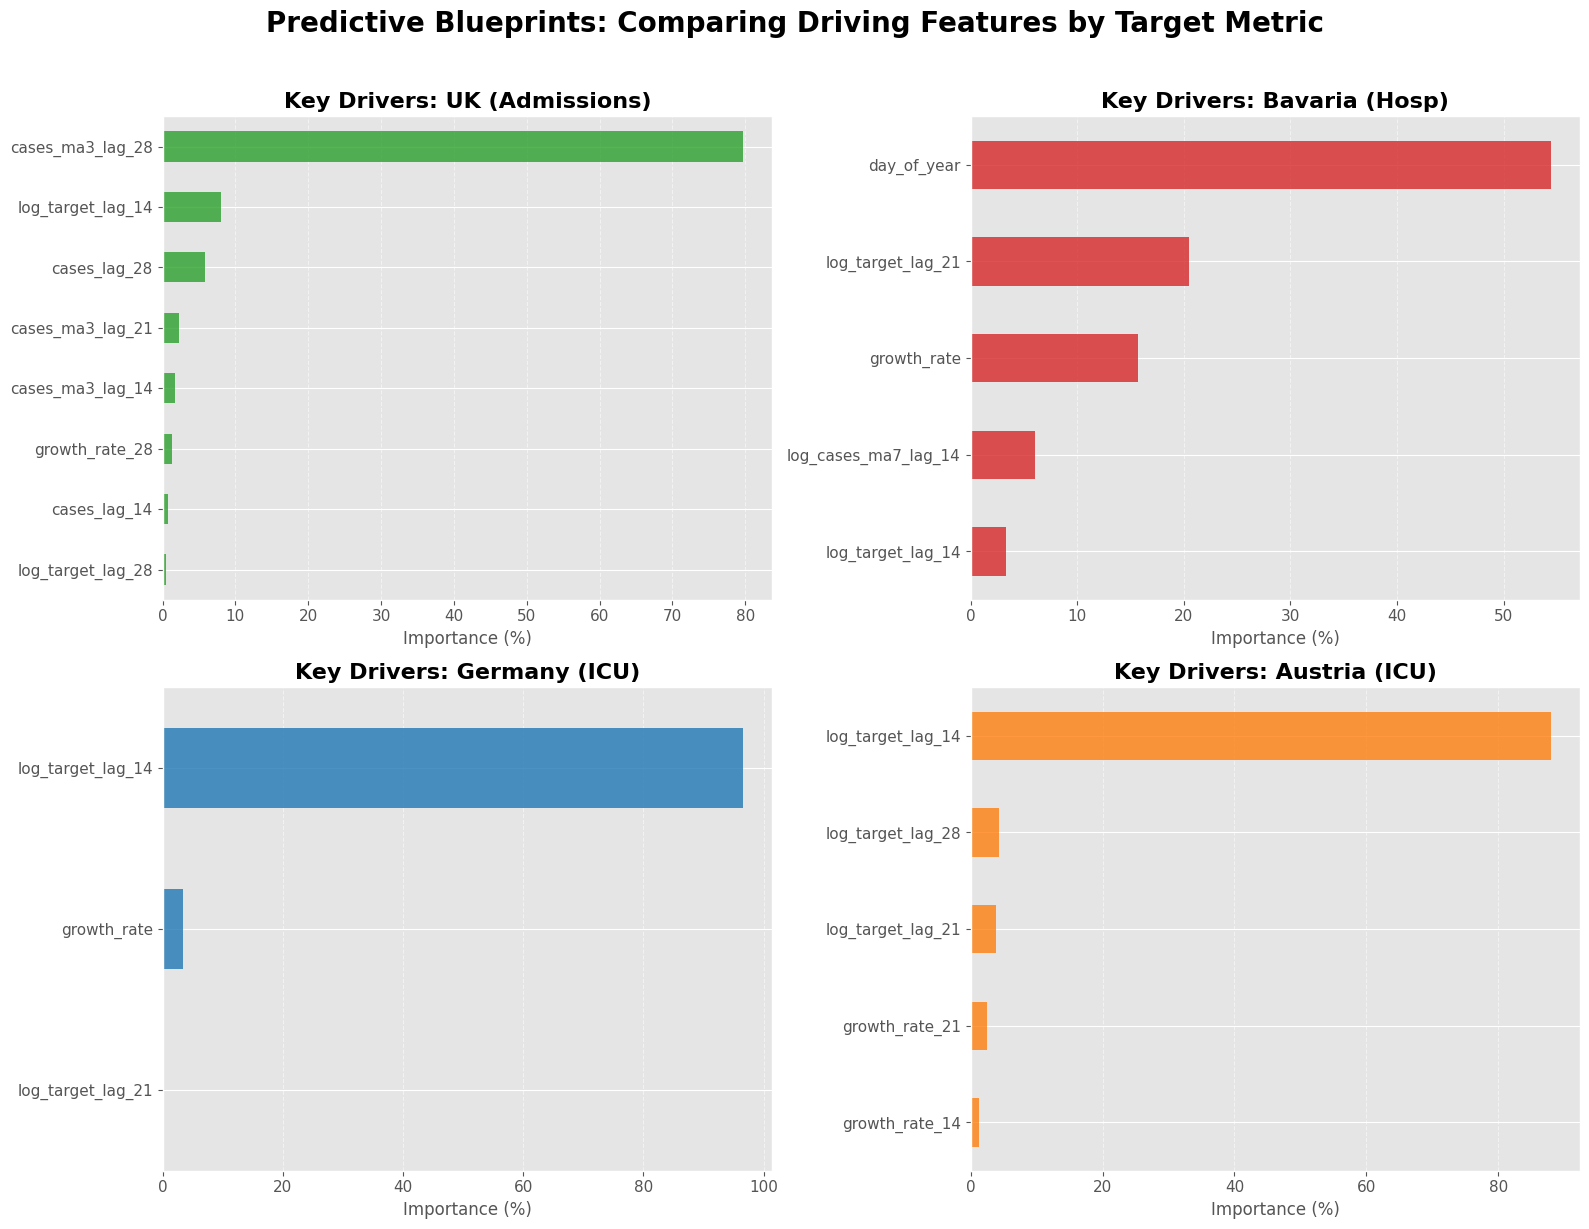

In [49]:
# =============================== 
# FEATURE IMPORTANCE (Grouped by Target)
# =============================== 
import matplotlib.pyplot as plt
import pandas as pd

# Define the order strictly: Admissions on top, ICU on bottom
plot_order = [
    ('UK (Admissions)', importance_uk, '#2ca02c'),
    ('Bavaria (Hosp)', importance_bavaria, '#d62728'),
    ('Germany (ICU)', importance_germany, '#1f77b4'),
    ('Austria (ICU)', importance_austria, '#ff7f0e')
]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, (region, series, color) in enumerate(plot_order):
    # Sort and take top features
    top_features = series.sort_values(ascending=True).tail(8)
    
    # Normalize to percentages
    top_features_pct = (top_features / top_features.sum()) * 100
    
    # Plot
    top_features_pct.plot(kind='barh', ax=axes[i], color=color, alpha=0.8)
    axes[i].set_title(f'Key Drivers: {region}', fontsize=16, fontweight='bold')
    axes[i].set_xlabel('Importance (%)', fontsize=12)
    axes[i].tick_params(axis='both', which='major', labelsize=11)
    axes[i].grid(axis='x', linestyle='--', alpha=0.5)

plt.suptitle("Predictive Blueprints: Comparing Driving Features by Target Metric", 
             fontsize=20, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

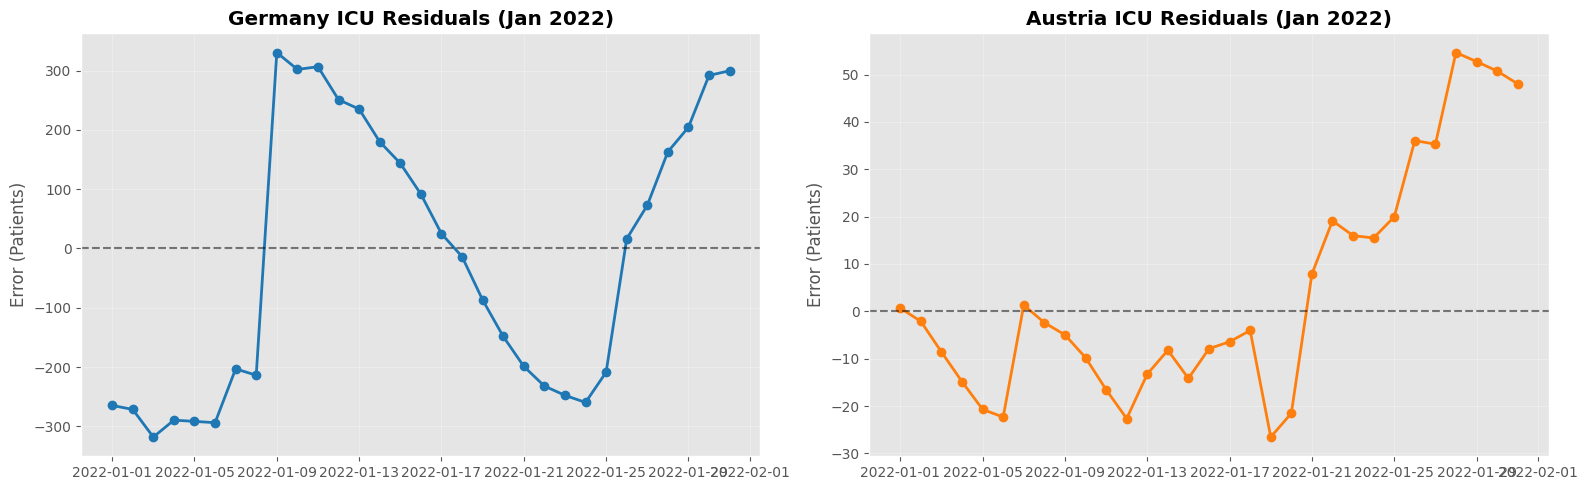

AUDIT NOTE: Residuals centered around zero indicate an unbiased model.


In [50]:
# Model Performance Evaluation: Residuals of ICU Admissions in Germany and Austria (Jan 2022)
# =============================== 
# RESIDUAL ANALYSIS
# =============================== 
import matplotlib.pyplot as plt

# 1. Setup Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5), sharey=False)

# 2. Germany Residuals (Actual - Predicted)
res_de = y_true_2022_de - y_pred_2022_de
ax1.plot(res_de.index, res_de, marker='o', color='#1f77b4', linewidth=2)
ax1.axhline(0, color='black', linestyle='--', alpha=0.5)
ax1.set_title('Germany ICU Residuals (Jan 2022)', fontweight='bold')
ax1.set_ylabel('Error (Patients)')
ax1.grid(alpha=0.3)

# 3. Austria Residuals (Actual - Predicted)
res_at = y_true_2022_at - y_pred_2022_at
ax2.plot(res_at.index, res_at, marker='o', color='#ff7f0e', linewidth=2)
ax2.axhline(0, color='black', linestyle='--', alpha=0.5)
ax2.set_title('Austria ICU Residuals (Jan 2022)', fontweight='bold')
ax2.set_ylabel('Error (Patients)')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("AUDIT NOTE: Residuals centered around zero indicate an unbiased model.")

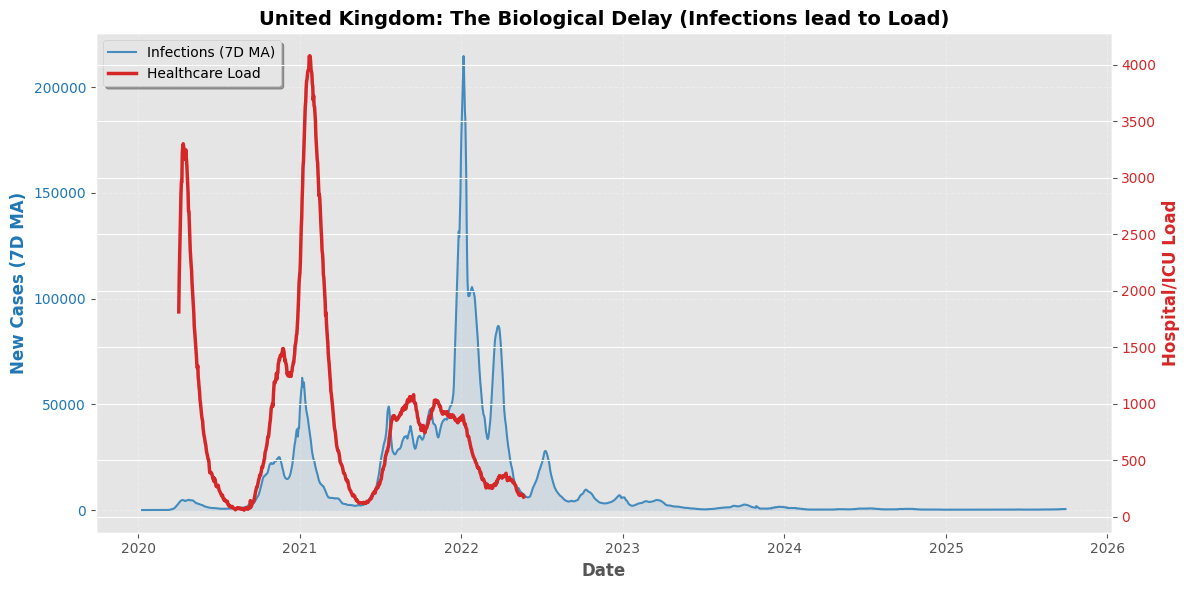

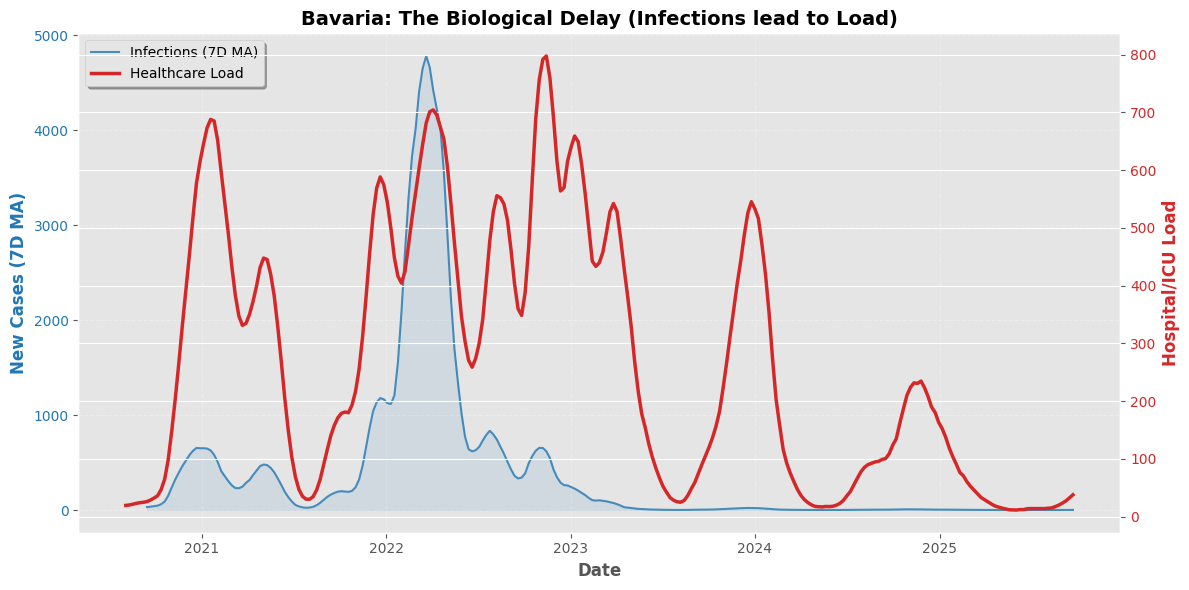

In [51]:
#Wave Dynamics Overlay: New Cases vs. Hospital/ICU Admissions in UK and Bavaria
# =============================== 
# WAVE DYNAMICS OVERLAY (HIGH CONTRAST)
# =============================== 
import matplotlib.pyplot as plt

def plot_wave_dynamics(df, region_name):
    fig, ax1 = plt.subplots(figsize=(12, 6))

    # --- 1. Identify Columns ---
    case_options = ['new_cases', 'Faelle_neu', 'newCasesBySpecimenDate']
    case_col = next((c for c in case_options if c in df.columns), None)

    target_options = ['hospital_admissions', 'newAdmissions', 'target', '7T_Hospitalisierung_Faelle', 'icu_patients']
    target_col = next((t for t in target_options if t in df.columns), None)

    if not case_col or not target_col:
        print(f"Skipping {region_name}: Missing data columns.")
        return

    # --- 2. High Contrast Colors ---
    color_cases = '#1f77b4'  # Strong Blue (Infections)
    color_hosp = '#d62728'   # Sharp Red (Healthcare Load)

    # --- 3. Plot Cases (Primary Axis) ---
    ax1.set_xlabel('Date', fontweight='bold')
    ax1.set_ylabel('New Cases (7D MA)', color=color_cases, fontweight='bold')
    
    cases_ma = df[case_col].rolling(7).mean()
    
    # Solid line with fill to make it very visible
    line1 = ax1.plot(df.index, cases_ma, color=color_cases, label='Infections (7D MA)', linewidth=1.5, alpha=0.8)
    ax1.fill_between(df.index, cases_ma, color=color_cases, alpha=0.1)
    ax1.tick_params(axis='y', labelcolor=color_cases)

    # --- 4. Plot Load (Secondary Axis) ---
    ax2 = ax1.twinx()
    ax2.set_ylabel('Hospital/ICU Load', color=color_hosp, fontweight='bold')
    
    line2 = ax2.plot(df.index, df[target_col], color=color_hosp, label='Healthcare Load', linewidth=2.5, zorder=10)
    ax2.tick_params(axis='y', labelcolor=color_hosp)

    # --- 5. Styling & Legend ---
    plt.title(f'{region_name}: The Biological Delay (Infections lead to Load)', fontsize=14, fontweight='bold')
    ax1.grid(True, linestyle='--', alpha=0.3)
    
    # Merge legends
    lines = line1 + line2
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc='upper left', frameon=True, shadow=True)
    
    plt.tight_layout()
    plt.show()

# Execute
try:
    # Use your specific dataframes
    plot_wave_dynamics(df_uk, "United Kingdom")
    plot_wave_dynamics(df, "Bavaria") 
except NameError as e:
    print(f"Dataframe not found: {e}. Ensure earlier cells were executed.")